# Comparison of lake chlorophyll levels to buffer zone land use using remote sensing data 

I will be investigating how the land use (Crop Land, Developed, Tree Cover, etc..) in a 50 meter buffer around lakes in Minnesota relate to chlorophyll levels, specifically at the peak of algal growth in September in 2025.

## Package Installation and Import

In [1]:
# Install if needed:
#%pip install requests pandas geopandas shapely rasterio pyproj tqdm matplotlib contextily

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd



# landcover
from requests import Session
import sys
sys.path.append('..')
from api_key import key
from tqdm.notebook import tqdm
from shapely.geometry import shape, mapping
from shapely import wkt
from rasterio.io import MemoryFile
from rasterio.mask import mask
import matplotlib.patches as mpatches
import contextily as ctx

## Exploratory Data Analysis
Review the project_EDA.ipynb file for the preliminary data loading and processing. Processed data was saved to .csv files to be used in this analysis as follows:
* buffer_zones.csv - geometry and area for 50 meter buffer zone around each body of water
* landuse_50m_buffers.csv - landuse categorization for the 50 meter buffer zones based on the proportion of pixel classification
* landuse_waterquality.csv - merged chlorophyll, water geometry, and bufferzone land use data

In [2]:
buffer_df = pd.read_csv('Data/buffer_zone.csv')
buffer_df.head()

,lake_id,lake_name,acres,chl_sept_2025,mean_chl_summer_2025,geometry,buffer_50m_acres
0,01000100,pine,373.578352,6.64,5.07,POLYGON ((-93.07480733436563 46.18449207011752...,92.222570
1,01000200,split rock,23.564396,12.07,13.35,POLYGON ((-93.16783523397069 46.40647540162632...,18.673337
2,01000300,sandabacka,27.635120,3.85,4.06,POLYGON ((-93.13992759679856 46.55221087487485...,17.117370
3,01000400,dutch,43.687367,4.02,4.42,POLYGON ((-93.13932494060849 46.54836930147139...,28.700297
4,01000600,mud,15.339665,3.46,3.46,POLYGON ((-93.06697020843744 46.64014040993508...,14.415326


In [3]:
landuse_df = pd.read_csv('Data/landuse_50m_buffers.csv')
landuse_df.head()

,lake_id,lake_name,lcmap_year,buffer_50m_acres,total_landcover_pixels,NoData_count,Developed_count,Developed_prop,Cropland_count,Cropland_prop,...,TreeCover_count,TreeCover_prop,Water_count,Water_prop,Wetland_count,Wetland_prop,Ice_Snow_count,Ice_Snow_prop,Barren_count,Barren_prop
0,01000100,pine,2020,92.222570,4722,0,375,0.079416,368,0.077933,...,1607,0.340322,935,0.198009,1415,0.299661,0,0.0,0,0.0
1,01000200,split rock,2020,18.673337,940,0,0,0.000000,36,0.038298,...,184,0.195745,266,0.282979,448,0.476596,0,0.0,0,0.0
2,01000300,sandabacka,2020,17.117370,856,0,0,0.000000,0,0.000000,...,76,0.088785,122,0.142523,658,0.768692,0,0.0,0,0.0
3,01000400,dutch,2020,28.700297,1465,0,0,0.000000,0,0.000000,...,262,0.178840,239,0.163140,964,0.658020,0,0.0,0,0.0
4,01000600,mud,2020,14.415326,736,0,0,0.000000,0,0.000000,...,0,0.000000,145,0.197011,591,0.802989,0,0.0,0,0.0


In [4]:
use_qual_df = pd.read_csv('Data/landuse_waterquality.csv')
use_qual_df.head()
use_qual_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9906 entries, 0 to 9905
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   lake_id                 9906 non-null   object 
 1   lake_name_x             9906 non-null   object 
 2   lcmap_year              9906 non-null   int64  
 3   buffer_50m_acres        9906 non-null   float64
 4   total_landcover_pixels  9906 non-null   int64  
 5   NoData_count            9906 non-null   int64  
 6   Developed_count         9906 non-null   int64  
 7   Developed_prop          9906 non-null   float64
 8   Cropland_count          9906 non-null   int64  
 9   Cropland_prop           9906 non-null   float64
 10  Grass_Shrub_count       9906 non-null   int64  
 11  Grass_Shrub_prop        9906 non-null   float64
 12  TreeCover_count         9906 non-null   int64  
 13  TreeCover_prop          9906 non-null   float64
 14  Water_count             9906 non-null   

### Example Lakes with Landuse Buffers and September Chlorophyll
I want to show what the lakes look like surrounded by their buffer zones look like by comparing two lakes that I know personally, Harriet in Minneapolis and Belle Taine in Nevis.

In [5]:
# target lakes
target_ids = ["27001600", "29014600"]  # Harriet, Belle Taine

# make lake_id formatting consistent
buffer_df["lake_id"] = buffer_df["lake_id"].astype(str).str.zfill(8)
use_qual_df["lake_id"] = use_qual_df["lake_id"].astype(str).str.zfill(8)

# rebuild geometries from CSV text
buffer_df["buffer_geom"] = buffer_df["geometry"].apply(wkt.loads)
use_qual_df["lake_geom"] = use_qual_df["geometry"].apply(wkt.loads)

# lake geometries from use_qual_df are projected UTM
lake_gdf = gpd.GeoDataFrame(
    use_qual_df.drop(columns=["geometry"]),
    geometry="lake_geom",
    crs="EPSG:26915"
).to_crs("EPSG:4326")

# buffer geometries from buffer_df are already lon/lat
buffer_gdf = gpd.GeoDataFrame(
    buffer_df.drop(columns=["geometry"]),
    geometry="buffer_geom",
    crs="EPSG:4326"
)

# keep only target lakes
lake_map = lake_gdf[lake_gdf["lake_id"].isin(target_ids)].copy()
buffer_map = buffer_gdf[buffer_gdf["lake_id"].isin(target_ids)].copy()

print(lake_map[["lake_id", "lake_name_y", "acres", "mean_chl_summer_2025", "majority_landuse", "max_prop"]])

       lake_id  lake_name_y        acres  mean_chl_summer_2025  \
3804  27001600      harriet   334.536311                  4.83   
4083  29014600  belle taine  1532.345070                  2.81   

     majority_landuse  max_prop  
3804        Developed  0.735937  
4083        TreeCover  0.566483  


In [6]:
# calculate the largest map window needed across both lakes
plot_windows = []

for lake_id in target_ids:
    lake = lake_map[lake_map["lake_id"] == lake_id]
    buffer = buffer_map[buffer_map["lake_id"] == lake_id]

    bounds = pd.concat([
        lake.geometry.bounds,
        buffer.geometry.bounds
    ])

    minx = bounds["minx"].min()
    miny = bounds["miny"].min()
    maxx = bounds["maxx"].max()
    maxy = bounds["maxy"].max()

    width = maxx - minx
    height = maxy - miny

    plot_windows.append((width, height))

max_width = max(w for w, h in plot_windows)
max_height = max(h for w, h in plot_windows)

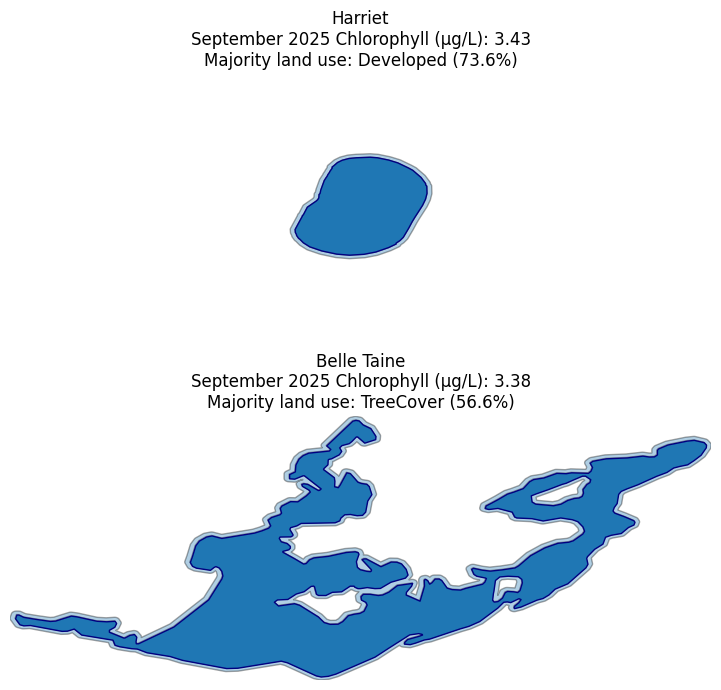

In [7]:
# calculate the largest map window needed across both lakes
plot_windows = []

for lake_id in target_ids:
    lake = lake_map[lake_map["lake_id"] == lake_id]
    buffer = buffer_map[buffer_map["lake_id"] == lake_id]

    bounds = pd.concat([
        lake.geometry.bounds,
        buffer.geometry.bounds
    ])

    minx = bounds["minx"].min()
    miny = bounds["miny"].min()
    maxx = bounds["maxx"].max()
    maxy = bounds["maxy"].max()

    width = maxx - minx
    height = maxy - miny

    plot_windows.append((width, height))

max_width = max(w for w, h in plot_windows)
max_height = max(h for w, h in plot_windows)

# Plot the maps

fig, axes = plt.subplots(2, 1, figsize=(10, 7))

for ax, lake_id in zip(axes, target_ids):

    lake = lake_map[lake_map["lake_id"] == lake_id]
    buffer = buffer_map[buffer_map["lake_id"] == lake_id]

    buffer.plot(ax=ax, alpha=0.35, edgecolor="black", linewidth=1)
    lake.plot(ax=ax, edgecolor="navy", linewidth=1)

    row = lake.iloc[0]

    # center each plot on its own lake/buffer
    bounds = pd.concat([
        lake.geometry.bounds,
        buffer.geometry.bounds
    ])

    center_x = (bounds["minx"].min() + bounds["maxx"].max()) / 2
    center_y = (bounds["miny"].min() + bounds["maxy"].max()) / 2

    # use the same extent for both maps
    ax.set_xlim(center_x - max_width / 2, center_x + max_width / 2)
    ax.set_ylim(center_y - max_height / 2, center_y + max_height / 2)

    ax.set_aspect("equal")

    ax.set_title(
        f"{row['lake_name_y'].title()}\n"
        f"September 2025 Chlorophyll (µg/L): {row['chl_sept_2025']:.2f}\n"
        f"Majority land use: {row['majority_landuse']} ({row['max_prop']:.1%})"
    )

    ax.set_axis_off()

plt.tight_layout()
plt.show()

In [8]:
lake_map[
    [
        "lake_id",
        "lake_name_y",
        "acres",
        "mean_chl_summer_2025",
        "chl_sept_2025",
        "majority_landuse",
        "max_prop",
        "Developed_prop",
        "Cropland_prop",
        "Grass_Shrub_prop",
        "TreeCover_prop",
        "Water_prop",
        "Wetland_prop"
    ]
]

,lake_id,lake_name_y,acres,mean_chl_summer_2025,chl_sept_2025,majority_landuse,max_prop,Developed_prop,Cropland_prop,Grass_Shrub_prop,TreeCover_prop,Water_prop,Wetland_prop
3804,27001600,harriet,334.536311,4.83,3.43,Developed,0.735937,0.735937,0.000000,0.000000,0.018273,0.245432,0.000358
4083,29014600,belle taine,1532.345070,2.81,3.38,TreeCover,0.566483,0.061645,0.017172,0.003907,0.566483,0.236451,0.108163


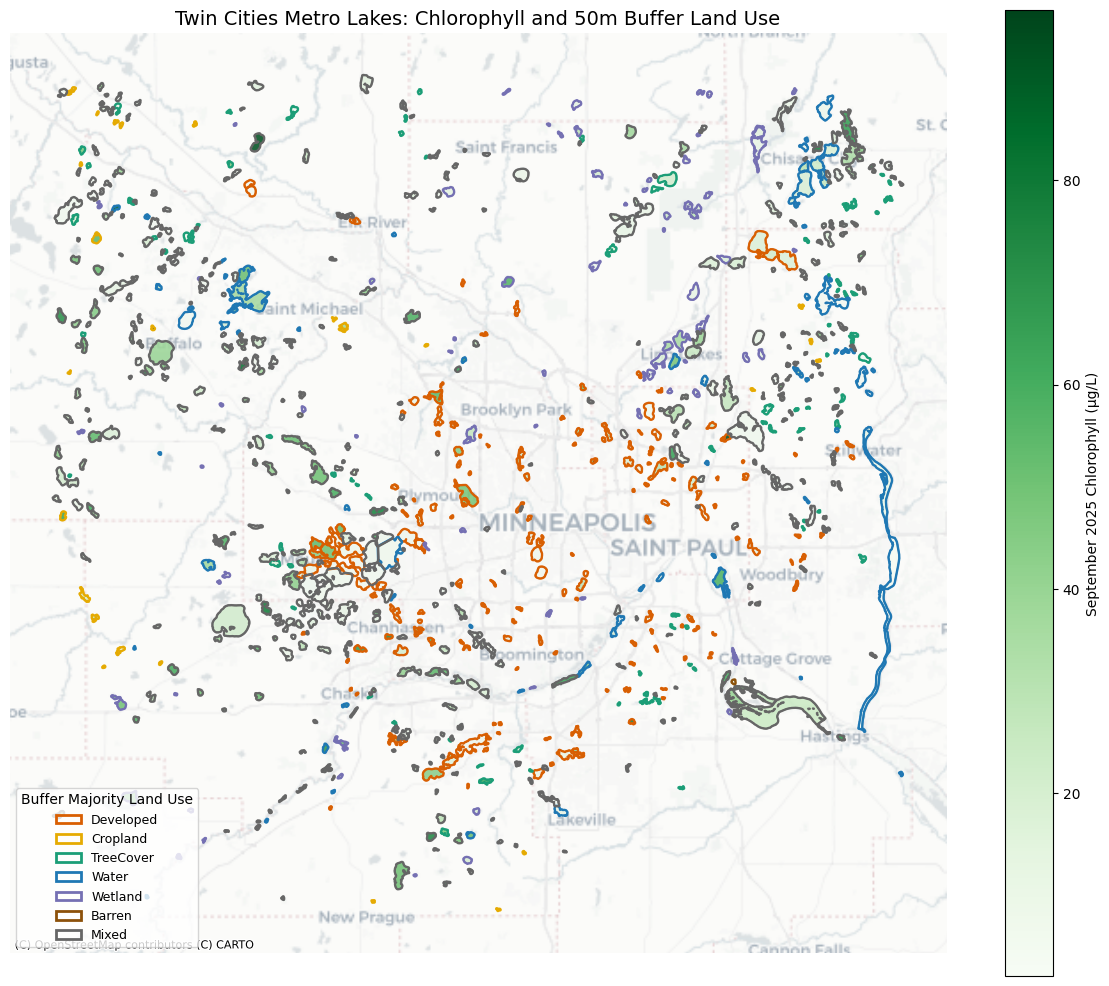

In [9]:
# plot of the lakes in the metro area with their buffer zone and september 2025 chlorophyll color coded

# Twin Cities metro bounding box in lon/lat
metro_bbox = (-94.05, 44.55, -92.75, 45.45)

# rebuild geometries if needed
use_qual_df["lake_geom"] = use_qual_df["geometry"].apply(wkt.loads)
buffer_df["buffer_geom"] = buffer_df["geometry"].apply(wkt.loads)

# standardize lake_id
use_qual_df["lake_id"] = use_qual_df["lake_id"].astype(str).str.zfill(8)
buffer_df["lake_id"] = buffer_df["lake_id"].astype(str).str.zfill(8)

# lake polygons
lake_gdf = gpd.GeoDataFrame(
    use_qual_df.drop(columns=["geometry"], errors="ignore"),
    geometry="lake_geom",
    crs="EPSG:26915"
).to_crs("EPSG:4326")

# buffer polygons
buffer_gdf = gpd.GeoDataFrame(
    buffer_df.drop(columns=["geometry"], errors="ignore"),
    geometry="buffer_geom",
    crs="EPSG:4326"
)

# filter to Twin Cities metro
metro_lakes = lake_gdf.cx[
    metro_bbox[0]:metro_bbox[2],
    metro_bbox[1]:metro_bbox[3]
].dropna(subset=["chl_sept_2025", "majority_landuse"])

metro_buffers = buffer_gdf[
    buffer_gdf["lake_id"].isin(metro_lakes["lake_id"])
].copy()

# bring land use category onto buffer data
metro_buffers = metro_buffers.merge(
    metro_lakes[["lake_id", "majority_landuse"]],
    on="lake_id",
    how="left"
)

# land use outline colors
landuse_colors = {
    "Developed": "#d95f02",
    "Cropland": "#e6ab02",
    "Grass_Shrub": "#66a61e",
    "TreeCover": "#1b9e77",
    "Water": "#1f78b4",
    "Wetland": "#7570b3",
    "Barren": "#8c510a",
    "Mixed": "#666666"
}

# convert to Web Mercator for basemap
metro_lakes_web = metro_lakes.to_crs(epsg=3857)
metro_buffers_web = metro_buffers.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))

# plot buffers first as colored outlines
for category, color in landuse_colors.items():
    subset = metro_buffers_web[metro_buffers_web["majority_landuse"] == category]
    if len(subset) > 0:
        subset.boundary.plot(
            ax=ax,
            color=color,
            linewidth=1.4,
            alpha=0.95
        )

# plot lakes filled by chlorophyll
metro_lakes_web.plot(
    ax=ax,
    column="chl_sept_2025",
    cmap="Greens",
    legend=True,
    edgecolor="black",
    linewidth=0.4,
    alpha=0.85,
    legend_kwds={"label": "September 2025 Chlorophyll (µg/L)"}
)

# add basemap underneath
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    alpha=0.8
)

ax.set_title(
    "Twin Cities Metro Lakes: Chlorophyll and 50m Buffer Land Use",
    fontsize=14
)

ax.set_axis_off()

# buffer color key
handles = [
    mpatches.Patch(facecolor="none", edgecolor=color, label=category, linewidth=2)
    for category, color in landuse_colors.items()
    if category in metro_buffers_web["majority_landuse"].dropna().unique()
]

ax.legend(
    handles=handles,
    title="Buffer Majority Land Use",
    loc="lower left",
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

plt.tight_layout()
plt.show()

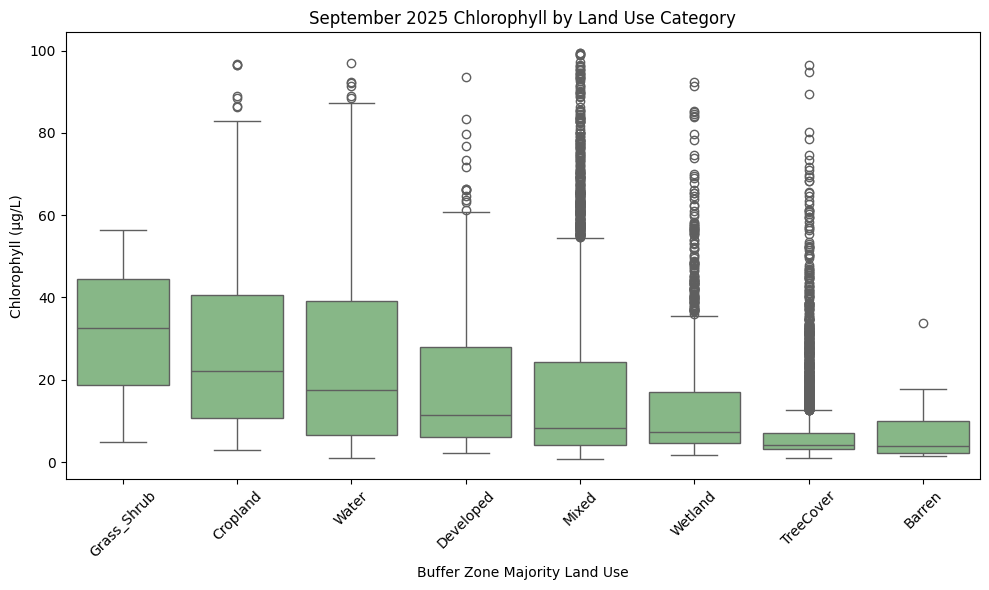

In [10]:
# box plot of September 2025 chlorophyll values for each land use category
category_order = (use_qual_df.groupby("majority_landuse")["chl_sept_2025"].median().sort_values(ascending=False).index)

plt.figure(figsize=(10,6))

sns.boxplot(data=use_qual_df, color="#7fbf7f", x="majority_landuse", y="chl_sept_2025", order=category_order)

plt.title("September 2025 Chlorophyll by Land Use Category")
plt.xlabel("Buffer Zone Majority Land Use")
plt.ylabel("Chlorophyll (µg/L)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Bootstrap 1 - Median Chlorophyll

In [11]:
# Overall Median Chlorophyll for lakes in September 2025
median_chla = use_qual_df["chl_sept_2025"].median()
print("Median Chlorophyll September 2025: ", median_chla)

Median Chlorophyll September 2025:  6.33


In [12]:
# bootstrap chlorophyll for 5000 replicates
med_boot = use_qual_df.copy()

replicates = []

for _ in range(5000) :
    replicates.append(med_boot.sample(frac=1, replace = True)['chl_sept_2025'].median())

In [13]:
# confidence interval
ci_lower = np.percentile(replicates, 2.5)
ci_upper = np.percentile(replicates, 97.5)

print(f"Median September chlorophyll: {median_chla:.2f}")
print(f"95% CI: ({ci_lower:.2f}, {ci_upper:.2f})")

Median September chlorophyll: 6.33
95% CI: (6.15, 6.51)


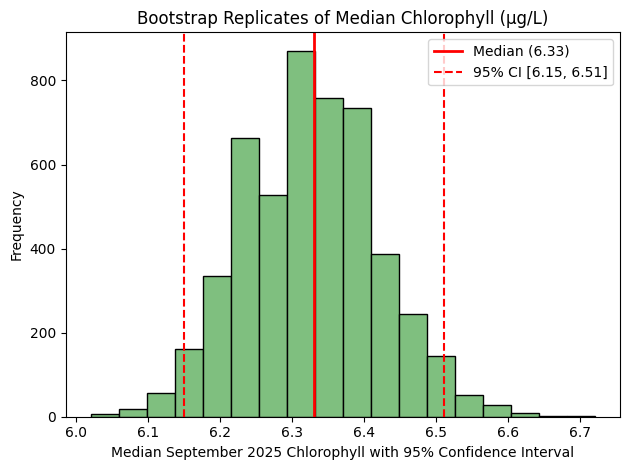

In [14]:
# histogram of bootstrap replicates and observed median

boot_med = np.median(replicates)

plt.hist(replicates, bins=18, color='#7fbf7f', edgecolor='black')
plt.axvline(median_chla, color='red', linestyle='-', linewidth=2, label=f'Median ({median_chla:.2f})')
plt.axvline(ci_lower, color='red', linestyle='--', lw=1.5, label=f'95% CI [{ci_lower:.2f}, {ci_upper:.2f}]')
plt.axvline(ci_upper, color='red', linestyle='--', lw=1.5)
plt.xlabel('Median September 2025 Chlorophyll with 95% Confidence Interval')
plt.ylabel('Frequency')
plt.title('Bootstrap Replicates of Median Chlorophyll (µg/L)')
plt.legend()
plt.tight_layout()
plt.show()

## Bootstrap 2 - Mean Chlorophyll by Land Use Category


In [15]:
# mean september 2025 chlorophyll by buffer zone land use
boot_table = use_qual_df.groupby("majority_landuse")["chl_sept_2025"].agg( observation_count="count", observed_mean="mean").reset_index()

# adding columns for the bootstrap values we'll fill in later
boot_table['boot_mean'] = pd.NA
boot_table['boot_lower_ci'] = pd.NA
boot_table['boot_upper_ci'] = pd.NA

In [16]:
# loop to bootstrap September 2025 chlorophyll in each buffer land use and save mean and CI

# 5000 bootstrap samples
n_sim = 5000

boot_samples = {}

# bootstrap for loop
for idx, row in boot_table.iterrows() :
    this_use = row['majority_landuse']
    this_chla = use_qual_df.query(f"majority_landuse == '{this_use}'")

    samples = []

    # sampling with replacement
    for _ in range(n_sim) :
        this_sample = this_chla.sample(n=len(this_chla), replace=True)
        samples.append(np.mean(this_sample['chl_sept_2025']))

    samples = pd.Series(samples)

    boot_samples[this_use] = samples

    # adding mean and confidence interval to the summary_table based on the table's index that's being run through the loop
    boot_table.loc[idx, 'boot_mean'] = samples.mean()
    boot_table.loc[idx, 'boot_lower_ci'] = samples.quantile(0.025)
    boot_table.loc[idx, 'boot_upper_ci'] = samples.quantile(0.975)

In [17]:
# Print summary table
boot_table

,majority_landuse,observation_count,observed_mean,boot_mean,boot_lower_ci,boot_upper_ci
0,Barren,18,7.611667,7.602907,4.325236,11.686111
1,Cropland,326,28.523712,28.501407,26.116071,30.931097
2,Developed,216,20.429954,20.440311,17.878163,23.120488
3,Grass_Shrub,3,31.310000,31.469004,4.98,56.36
4,Mixed,3939,17.621186,17.620106,17.020591,18.237229
5,TreeCover,3337,7.713917,7.712185,7.38074,8.060382
6,Water,652,25.161810,25.169957,23.488312,26.876292
7,Wetland,1415,13.687067,13.683748,12.946821,14.429379


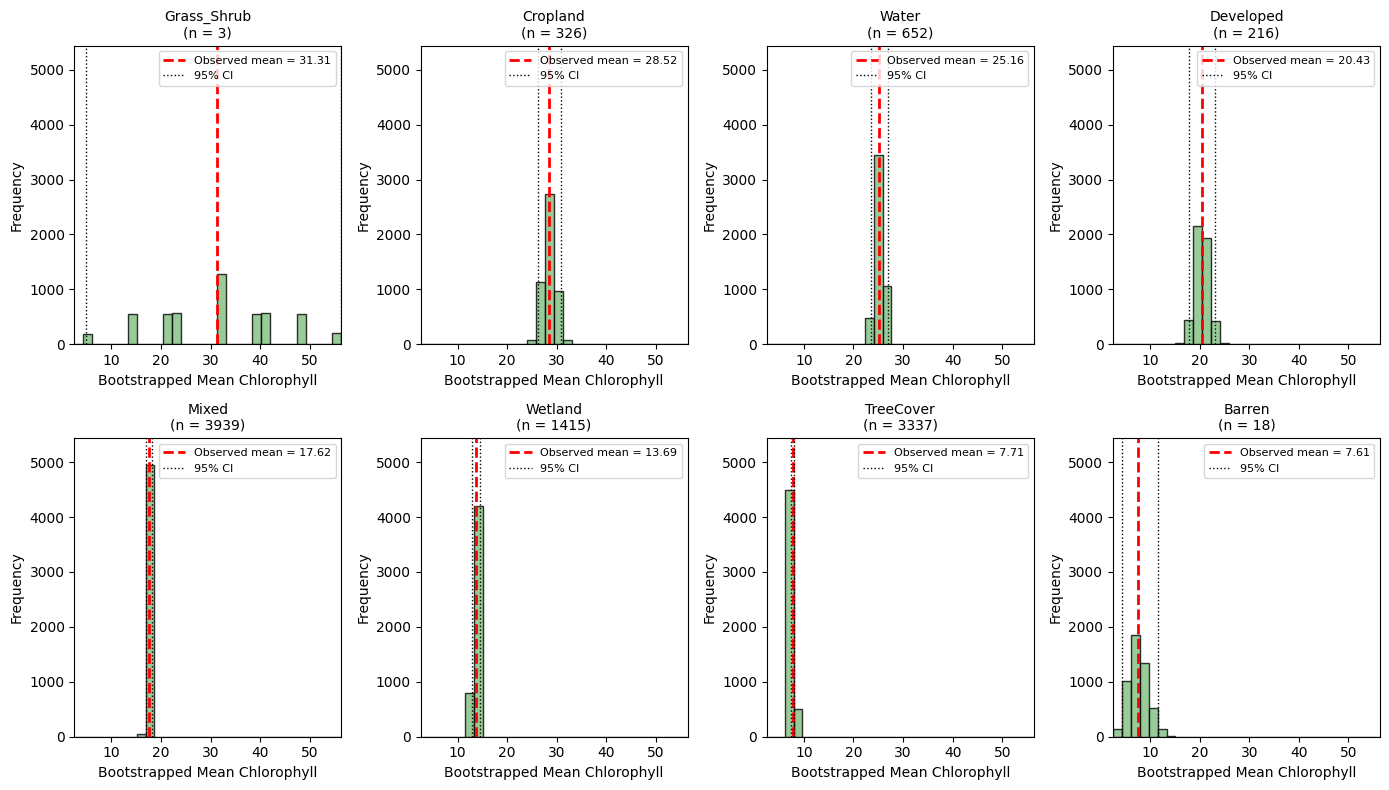

In [18]:
# Histogram of chlorophyll bootsrap results for each land use category

# order categories by observed mean
category_order = (boot_table.sort_values("observed_mean", ascending=False)["majority_landuse"].tolist())

# fixed axes for comparison
x_min = min(boot_samples[cat].min() for cat in category_order)
x_max = max(boot_samples[cat].max() for cat in category_order)
y_max = 0

# estimate shared y max
for cat in category_order:
    counts, _ = np.histogram(boot_samples[cat], bins=30, range=(x_min, x_max))
    y_max = max(y_max, counts.max())

fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()

for i, cat in enumerate(category_order):
    ax = axes[i]

    ax.hist(boot_samples[cat],bins=30,range=(x_min, x_max),color="#7fbf7f",edgecolor="black",alpha=0.8)

    observed_mean = boot_table.loc[boot_table["majority_landuse"] == cat,"observed_mean"].iloc[0]
    lower_ci = boot_table.loc[boot_table["majority_landuse"] == cat,"boot_lower_ci"].iloc[0]
    upper_ci = boot_table.loc[boot_table["majority_landuse"] == cat,"boot_upper_ci"].iloc[0]
    n_obs = boot_table.loc[boot_table["majority_landuse"] == cat,"observation_count"].iloc[0]

    ax.axvline(observed_mean, color="red", linestyle="--", linewidth=2,label=f"Observed mean = {observed_mean:.2f}")
    ax.axvline(lower_ci, color="black", linestyle=":", linewidth=1)
    ax.axvline(upper_ci, color="black", linestyle=":", linewidth=1,label="95% CI")

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, y_max * 1.1)

    ax.set_title(f"{cat}\n(n = {n_obs})", fontsize=10)
    ax.set_xlabel("Bootstrapped Mean Chlorophyll")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

# remove unused plots
for j in range(len(category_order), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

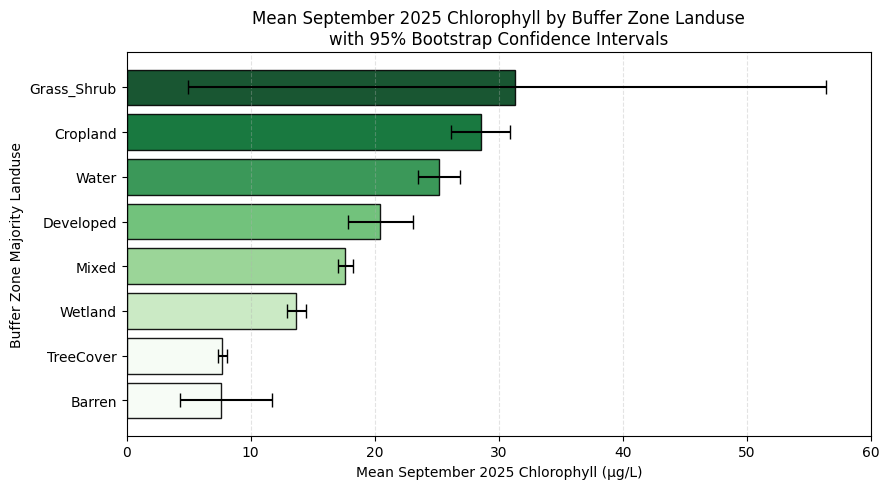

In [19]:
# Bars showing mean chlorophyll for each buffer land use with the 95% confidence intervals

plot_data = boot_table[['majority_landuse', 'observed_mean', 'boot_lower_ci', 'boot_upper_ci']].copy()
plot_data = plot_data.sort_values('observed_mean')

# distance from mean to lower and upper CI
lower_error = plot_data['observed_mean'] - plot_data['boot_lower_ci']
upper_error = plot_data['boot_upper_ci'] - plot_data['observed_mean']
# stacks the distance to the lower CI from the mean and the upper CI from the mean
x_errors = [lower_error, upper_error]

fig, ax = plt.subplots(figsize=(9, 5))

norm = plt.Normalize(plot_data["observed_mean"].min(),plot_data["observed_mean"].max())
colors = plt.cm.Greens(norm(plot_data["observed_mean"]))

ax.barh(
    y=plot_data['majority_landuse'],
    width=plot_data['observed_mean'],
    xerr=x_errors,
    color=colors,
    edgecolor='black',
    alpha=0.9,
    capsize=5
)

ax.set_xlabel('Mean September 2025 Chlorophyll (µg/L)')
ax.set_ylabel('Buffer Zone Majority Landuse')
ax.set_title('Mean September 2025 Chlorophyll by Buffer Zone Landuse\nwith 95% Bootstrap Confidence Intervals')
ax.set_xlim(0, 60)
ax.grid(axis='x', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.show()

## Permutation Test - F Statistic of Land Use Category x September Chlorophyll

Compare between-group variation in chlorophyll to within-group variation in chlorophyll. A large F indicates the mean chlorophyll are spread far apart relative to the noise withing each land use category and a small F indicates the land use categories look like they have the same chlorophyll distribution.

$$F = \frac{\text{between-group variability}}{\text{within-group variability}}$$

The land use labels will be shuffled and the f-statistic will be re-calculated for this permutation test. The repetition of this suffling will create the null distribution that the observed F-statistic can be compared to.

In [20]:
# creating a summary table with the body of water count, median september chl-a, mean september chl-a, stdev chl-a value for each land use category
summary_table = (
    use_qual_df
    .groupby("majority_landuse")["chl_sept_2025"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std"
    )
    .reset_index()
)

summary_table

,majority_landuse,count,mean,median,std
0,Barren,18,7.611667,3.935,8.355256
1,Cropland,326,28.523712,22.010,21.717943
2,Developed,216,20.429954,11.445,19.840243
3,Grass_Shrub,3,31.310000,32.590,25.713905
4,Mixed,3939,17.621186,8.280,19.507237
5,TreeCover,3337,7.713917,4.140,9.972857
6,Water,652,25.161810,17.605,22.359135
7,Wetland,1415,13.687067,7.240,14.455810


/var/folders/sf/gq7bmv9j1bq7b7tn2rvctcw40000gn/T/ipykernel_11422/3094128337.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cat,labels=category_order,patch_artist=True,medianprops=dict(color="black", linewidth=2))


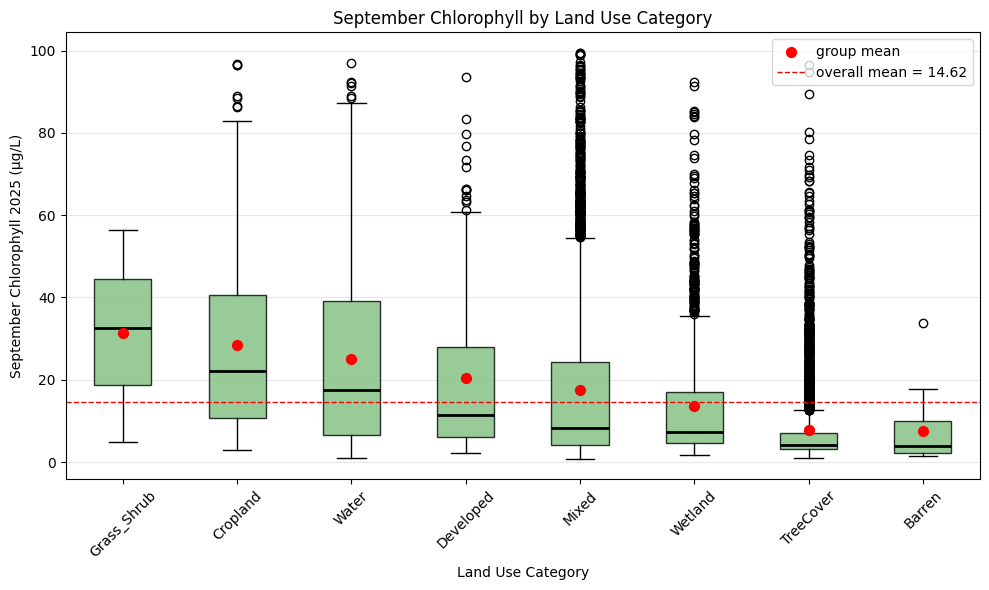

In [21]:
# Boxplots of the september chlorophyll by majority landuse category. The observed F-statistic will be the separation in means vs the shape of the box plot


# group + order by median (same logic you used)
category_order = use_qual_df.groupby("majority_landuse")["chl_sept_2025"].median().sort_values(ascending=False).index
groups = use_qual_df.groupby("majority_landuse")

# prepare data for boxplot
data_by_cat = [groups.get_group(cat)["chl_sept_2025"].dropna().values for cat in category_order]

# summary stats (for means)
group_summary = use_qual_df.groupby("majority_landuse")["chl_sept_2025"].agg(["mean", "median"])

# plot
fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(data_by_cat,labels=category_order,patch_artist=True,medianprops=dict(color="black", linewidth=2))
for patch in bp["boxes"]:
    patch.set_facecolor("#7fbf7f")  
    patch.set_alpha(0.8)

# overlay group means
means = [group_summary.loc[cat, "mean"] for cat in category_order]

ax.scatter(range(1, len(category_order) + 1),means,color="red",s=50,zorder=5,label="group mean")

# overall mean line
grand_mean = use_qual_df["chl_sept_2025"].mean()

ax.axhline(grand_mean,color="red",linestyle="--",linewidth=1,label=f"overall mean = {grand_mean:.2f}")

# labels + styling
ax.set_ylabel("September Chlorophyll 2025 (µg/L)")
ax.set_xlabel("Land Use Category")
ax.set_title("September Chlorophyll by Land Use Category")

ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Computing Observed F-Statistic
Quotient of of between group sum of squares (SSB) and within group sum of squares (SSW)

In [22]:
def calc_f_stat(values, groups):
    """Compute one-way ANOVA F-statistic from raw arrays."""
    values = np.asarray(values)
    groups = np.asarray(groups)
    grand_mean = values.mean()
    n_total = len(values)
    levels = np.unique(groups)
    k = len(levels)

    ss_between = 0.0
    ss_within = 0.0
    for lvl in levels:
        x = values[groups == lvl]
        n_g = len(x)
        ss_between += n_g * (x.mean() - grand_mean) ** 2
        ss_within += ((x - x.mean()) ** 2).sum()

    ms_between = ss_between / (k - 1)
    ms_within = ss_within / (n_total - k)
    return ms_between / ms_within, ss_between, ss_within, k, n_total


chla = use_qual_df["chl_sept_2025"].values
use = use_qual_df["majority_landuse"].values

f_obs, ssb, ssw, k, n_total = calc_f_stat(chla, use)
df_between = k - 1
df_within = n_total - k

print(f"Between-group SS: {ssb:.2f}  (df = {df_between})")
print(f"Within-group  SS: {ssw:.2f}  (df = {df_within})")
print(f"Mean square between: {ssb / df_between:.3f}")
print(f"Mean square within : {ssw / df_within:.3f}")
print(f"\nObserved F-statistic: {f_obs:.3f}")


Between-group SS: 340352.93  (df = 7)
Within-group  SS: 2691700.16  (df = 9898)
Mean square between: 48621.847
Mean square within : 271.944

Observed F-statistic: 178.794


### Permutation test on F-Statistic
Shuffle land use labels and recompute the F-statistic to generate data under null hypothesis. Compare the observed F to the distribution of permuted F values and calculate the p-value.

In [23]:
rng = np.random.default_rng(seed=631)
n_replicates = 5000
permuted_F = np.empty(n_replicates)

for i in range(n_replicates):
    shuffled_use = rng.permutation(use)
    permuted_F[i], _, _, _, _ = calc_f_stat(chla, shuffled_use)

p_value_F = (permuted_F >= f_obs).mean()

print(f"Observed F: {f_obs:.3f}")
print(f"Permutation p-value: {p_value_F:.4f}")

Observed F: 178.794
Permutation p-value: 0.0000


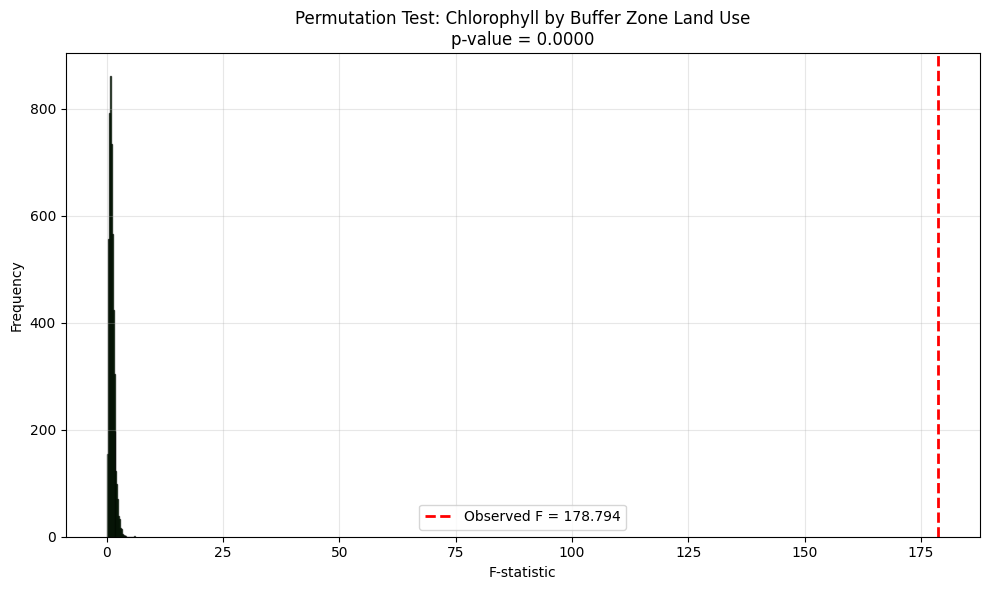

In [24]:
plt.figure(figsize=(10, 6))
plt.hist(permuted_F, bins=30, color="green", edgecolor="black", alpha=0.7)
plt.axvline(f_obs, color="red", linestyle="--", linewidth=2,
            label=f"Observed F = {f_obs:.3f}")
plt.xlabel("F-statistic")
plt.ylabel("Frequency")
plt.title(f"Permutation Test: Chlorophyll by Buffer Zone Land Use\np-value = {p_value_F:.4f}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The mean square (variance) between groups is much higher than the mean square (vairance) within groups which gave us a very large F-statistic of 179. When this p-value is calculated for this observation against the f-statistics found under the null hypothesis, we get a value that is approaching 0. This indicates that it's highly improbable that the variation in mean chlorophyll among land use groups is due to chance - we'd reject the null hypothesis in favor of the alternative hypothesis that the mean chlorophyll and buffer zone land use is correlated.